# Auto-ML for 008

In [1]:
import pandas as pd
import numpy as np
import h2o
from h2o.automl import H2OAutoML
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score, max_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read data
read_data=pd.read_csv("D:/Man/Earth and Environment/Manchester_data003-008/008_manchester_processed.csv")
read_data=read_data.sort_values(by='time').reset_index(drop=True)
data=read_data.drop(columns=['lat','lon','time'],errors='ignore')

features=['FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'TREFHT', 'UBOT', 'VBOT','year','month']
target='TREFMXAV_U'

# spliting dataset
train_df=data[(data['year']>=2006) & (data['year']<=2040)].copy()
test_df=data[(data['year']>2040) & (data['year']<2050)].copy()

print(f'training set:{len(train_df)},validation set:{len(test_df)}')

training set:12323,validation set:3152


In [3]:
# init and upload
h2o.init(max_mem_size='4G')

h2o_train=h2o.H2OFrame(train_df)
h2o_test=h2o.H2OFrame(test_df)

y='TREFMXAV_U'
x=[col for col in features if col != y]

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Temurin-11.0.28+6 (build 11.0.28+6, mixed mode)
  Starting server from C:\Users\Administrator\AppData\Roaming\Python\Python313\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\ADMINI~1\AppData\Local\Temp\tmph2i8gmjd
  JVM stdout: C:\Users\ADMINI~1\AppData\Local\Temp\tmph2i8gmjd\h2o_Administrator_started_from_python.out
  JVM stderr: C:\Users\ADMINI~1\AppData\Local\Temp\tmph2i8gmjd\h2o_Administrator_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Europe/London
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,18 days
H2O_cluster_name:,H2O_from_python_Administrator_m4nwnk
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,4 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [4]:
# training
aml=H2OAutoML(max_models=10,seed=42,max_runtime_secs=600)

aml.train(x=x,y=y,training_frame=h2o_train,leaderboard_frame=h2o_test)

AutoML progress: |
16:43:43.12: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),7/10
# GBM base models (used / total),6/6
# DRF base models (used / total),0/2
# DeepLearning base models (used / total),1/1
# GLM base models (used / total),0/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None


C:\Users\Administrator\AppData\Roaming\Python\Python313\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\Administrator\AppData\Local\Temp\ipykernel_7736\3415188497.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='percentage', y='variable', data=varimp_df.head(10), palette='RdBu')


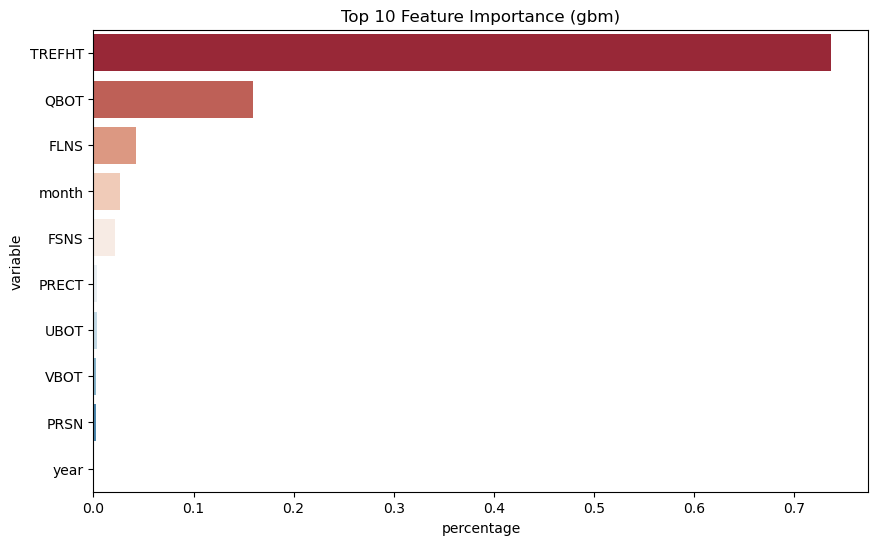

In [5]:
# feature importance
lb_df = aml.leaderboard.as_data_frame()

best_single_model_id = None
for model_id in lb_df['model_id']:
    if "StackedEnsemble" not in model_id:
        best_single_model_id = model_id
        break

if best_single_model_id:
    best_single_model = h2o.get_model(best_single_model_id)
    
    varimp_df = best_single_model.varimp(use_pandas=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='percentage', y='variable', data=varimp_df.head(10), palette='RdBu')
    plt.title(f'Top 10 Feature Importance ({best_single_model.algo})')
    plt.show()
else:
    print("Single model not found，check aml.leaderboard")

In [6]:
# test
test=aml.leader.predict(h2o_test)
test_dataframe=test.as_data_frame().reset_index(drop=True)

# evalution
y_true = test_df[target].values
y_pred = test_dataframe['predict'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
r2 = r2_score(y_true, y_pred)
max_err = max_error(y_true, y_pred)

print("\n" + "="*30)
print(f"Final Evaluation (H2O Leader):")
print(f"MAE      : {mae:.4f}") 
print(f"RMSE     : {rmse:.4f}")    
print(f"R-Squared: {r2:.4f}")     
print(f"Max Error: {max_err:.4f}")  
print("="*30)

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%

Final Evaluation (H2O Leader):
MAE      : 0.5008
RMSE     : 0.6766
R-Squared: 0.9830
Max Error: 3.4034


C:\Users\Administrator\AppData\Roaming\Python\Python313\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [7]:
# predict
pred_raw=data[(data['year']>=2050) & (data['year']<=2080)].copy()
pred_data=pred_raw.drop(columns=['lat','lon','time'],errors='ignore').reset_index(drop=True)

pred_h2o=h2o.H2OFrame(pred_data)

future_preds=aml.leader.predict(pred_h2o)
future_preds_df = future_preds.as_data_frame().reset_index(drop=True)

pred_data['pred'] = future_preds_df.iloc[:, 0].values

print(pred_data[['year','month','day','TREFMXAV_U','pred']].head())


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
   year  month  day  TREFMXAV_U       pred
0  2050      1    1    12.22982  12.888653
1  2050      1    2    13.54867  13.400531
2  2050      1    3    13.10415  11.649850
3  2050      1    4     8.24260   9.063196
4  2050      1    6    11.39813  11.690064


C:\Users\Administrator\AppData\Roaming\Python\Python313\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
